# Lecture 7

Up to now it has all been mathematics: what a probability is, what a distribution
is, how a histogram estimates one, and how to summarise a distribution with a mean and a variance.
None of it ran on a computer.

This notebook is the other half. Everything here is an *algorithm* for something derived there:

* **Random number generation** — a pseudo-random generator built from scratch, and then
  inversion, which turns uniform random numbers into any distribution whose cumulative you can
  invert.
* **Numerical function handling** — `arange` and `linspace` written by hand, then used to plot
  and minimise a function.
* **Histograms** — the estimator of $P(x)$, implemented so that you know exactly what
  `np.histogram` is doing.
* **Accept/reject** — sampling from a distribution you can evaluate but not integrate, and, from
  the same loop, **Monte Carlo integration**.

Two habits carry over from earlier and get used throughout: closures — functions that return
functions and remember their own state — and the functional style, where data flows through a
composition of functions rather than being mutated in place.

## Mean/Variance

For lab 3, remember the equations for mean/variance. If you have a data sample ${x_1, x_2, ..., x_N}$ the mean is:

$$ 
\bar{x} = \frac{1}{N}\sum_{i=1}^{N} x_i
$$

and the variance is:

$$
s^2 = \frac{1}{N-1} \sum_{i=1}^{N} (x_i - \bar{x})^2
$$

Two things about that second formula worth remembering, both covered earlier.

The $N-1$ is the **Bessel correction**. To compute the variance you need the mean — and you
didn't know the mean either, you estimated it from the same data. That estimate used up one
degree of freedom, and dividing by $N-1$ instead of $N$ accounts for it. For large $N$ it makes
almost no difference; for small $N$ it does, which is exactly when you should be paying attention.

And this formula is the same thing as $\mathbb{E}[x^2] - \mu^2$, just rearranged. The version
here, summing squared distances from the mean, is usually the easier one to write code for.

## Random Number Generator

We have learned about probability distributions and how data is generally a collection of random variables drawn from probability distributions. 

We also have discussed that analysis of a dataset is often really just trying to characterize the probability distributions of the random variables. Once we understand those probability distributions, we can then make predictions about future data.

But we can also create (e.g. simulate) new data from the probability distributions. 

There are two ways to do it.

You can **rely on a natural random process** — thermal noise in a circuit, a quantum
measurement, the timing jitter of your keystrokes. These are genuine sources of entropy, and
your operating system collects them. The catch is that entropy arrives at whatever rate the
physical process supplies it, so reading from such a source is *blocking* and *rate-limited*.
If you need ten million random numbers for a simulation, you will be waiting.

The other way is a **pseudo-random** number generator, which is what we will build. Three
properties define it:

* it starts from a **key**, or **seed**
* it is completely **deterministic** — same seed, same sequence, every time
* it **repeats eventually**, once the sequence comes back round to a value it has already
  produced

That first pair sounds like a weakness and is often a feature. If a simulation starts from a
fixed seed, then whatever happens in that simulation happens identically the next time you run
it. A bug that appears on the four-thousandth random draw is reproducible. Without that, it
isn't.

So how do we get a computer to generate data (e.g. random variables) from probability distributions? First, think about generating random numbers in a computer.

In [1]:
# Setup to make historgrams later...
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

The classic construction is the **linear congruential generator**. Keep one number
around — the current state — and produce the next one from it:

$$x_{n+1} = (a\,x_n + b) \bmod m$$

Pick $a$ and $b$ large, and $m$ a large prime. `mod` is Python's `%`: the remainder after
division, which is what keeps the values from running off to infinity and confines them to the
range $0$ to $m-1$. Divide by $m$ at the end and you have a number between 0 and 1.

The seed is $x_0$, the value the chain starts from. Everything after it follows deterministically,
which is exactly the property described above.

Two things to notice in the implementation below. The generator is a **function that returns a
function** — `uniform_generator` hands you back `random`, which remembers its own state. That is
a closure, the same construction we saw earlier. And the state is updated with `nonlocal`, which
is the subject of the note after it.

In [2]:
# Ignore following line for now... useful for explanation of non-local
x="Foo"

def uniform_generator(seed=123124.):
    a=1111111
    b=2222222
    m=6700417 # This is a large prime number
    x=seed
    
    def random():
        nonlocal x
        x=(a*x+b)%m
        return x/m  # divide by m to set range to 0->1
    
    return random

Quick side note: The use of `nonlocal`. In python, functions have their own local scope where references to variables created in the function are kept with the instance of the call to the function. The function has access to the scope from which it was defined as well as the global scope. When searching for a variable, python looks in the local scope first and works itself to the global scope. However, variable assignment causes a new variable within this local scope. Therefore in the in the case above, the assignment `x=(a*x+b)%m` will supercede `x=seed`. `nonlocal` tells python to use the variable in the previous scope.

In [3]:
my_uniform=uniform_generator()

In [4]:
random_numbers=list()
for _ in range(10):
    random_numbers.append(my_uniform())

In [5]:
random_numbers

[0.6326616686692783,
 0.6709910741376246,
 0.8950304137787245,
 0.46973837598465884,
 0.8083329739029675,
 0.9906205837636672,
 0.7591005156843224,
 0.26473680667934546,
 0.30966057784164774,
 0.6059604946975689]

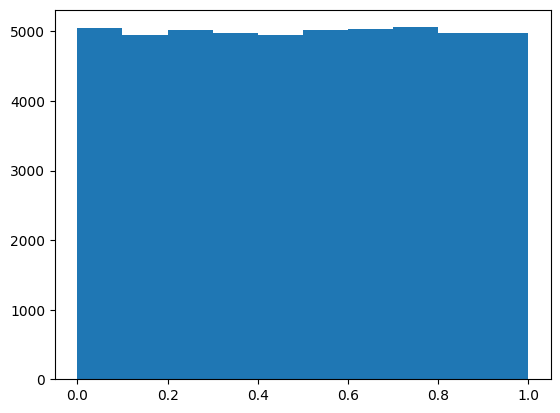

In [6]:
random_numbers=list()
for _ in range(50000):
    random_numbers.append(my_uniform())
_=plt.hist(random_numbers,bins=10)

## Exponential Generator

**Reminder.** Uniform random numbers are all a computer gives you. To get any
*other* distribution, one general method is **inversion**: take the cumulative $F$ of the density
you want, draw $u$ uniformly on $(0,1)$, and push it backwards through $F$.

$$u \sim \text{uniform}(0,1) \qquad x = F^{-1}(u) \qquad \Rightarrow \qquad x \sim f(x)$$

We saw the picture and the argument earlier for why that lands you in the right places. Here we
just do it — because for the exponential the algebra comes out in three lines, and the result
*is* the generator below.

The density is $P(t) = \frac{1}{\tau}e^{-t/\tau}$ for $t \ge 0$, so the cumulative is

$$F(T) = \int_0^T \frac{e^{-t/\tau}}{\tau}\,dt = \left[-e^{-t/\tau}\right]_0^T = 1 - e^{-T/\tau}$$

Set that equal to $u$ and solve:

$$1 - e^{-T/\tau} = u
\;\Rightarrow\; e^{-T/\tau} = 1 - u
\;\Rightarrow\; -\frac{T}{\tau} = \ln(1-u)$$

$$\boxed{\;T = -\tau \ln(1-u)\;}$$

Read the code below against that last line. It calls the uniform generator you already wrote and
takes one logarithm: no loop, no rejection, nothing thrown away. **That is what "inversion is the
cheapest method" means in practice** — and it is exactly what you give up in the next section.

In [7]:
import math

def generate_exp(tau,seed=32144):
    my_uniform=uniform_generator(seed)
    
    def generator():
        u = my_uniform()
        return -tau*(math.log(1.-u))
    
    return generator

In [8]:
my_exp_generator= generate_exp(10.)

In [9]:
my_exp_generator()

11.372504436305544

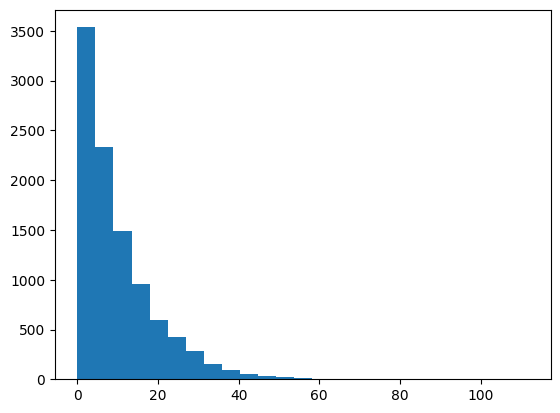

In [10]:
random_numbers=list()
for _ in range(10000):
    random_numbers.append(my_exp_generator())
_=plt.hist(random_numbers,bins=25)

## Scaling/Shifting

Reminder about lab 3: unless explicitly specified, don't use numpy. 

In the beginning of Lab 3 you are asked to take random numbers between 0 and 1 and scale and shift them to be between $x_{min}$ and $x_{max}$. The formula is pretty basic. If $x_0$ is between 0 and 1 then $x$ computed as:
$$
x = x_{min} + x_0\,(x_{max}-x_{min})
$$
will be between $x_{min}$ and $x_{max}$.

Read it as two steps, which is where the section's name comes from. **Scale** first: multiplying
$x_0$ by $(x_{max}-x_{min})$ stretches the interval $[0,1]$ so that it is the right *width*.
Then **shift**: adding $x_{min}$ slides it so that it starts in the right *place*. Check the two
ends — $x_0 = 0$ gives $x_{min}$, and $x_0 = 1$ gives $x_{max}$.

**Note.** A more common task is the *inverse*:
 $x = (x_0 - x_{min})/(x_{max}-x_{min})$. This expression takes an $x$
 already in $[x_{min}, x_{max}]$ and normalises it down to $[0,1]$. Later in the course, we'll discuss how such rescaling improves training Machine Learning models when using gradient decent.

In your solution, you'll most likely generate $x_0$ one by one, compute $x$, and store $x$ into a list to be returned from your function.


## Min, Max, ArgMin, ArgMax

Consider a list of random numbers:

In [11]:
import random
data = [random.random() for _ in range(100)]

In [12]:
data

[0.08964054583482584,
 0.6446013579967728,
 0.06831549381754887,
 0.1261030077546268,
 0.8050338001859642,
 0.5391070326192396,
 0.8166537096031213,
 0.5355212006486283,
 0.07953683599332861,
 0.5178103670102663,
 0.13387808516885458,
 0.11875399208504456,
 0.8113587112303585,
 0.6706297311421572,
 0.590695830311712,
 0.9038211094469676,
 0.4833248991054352,
 0.6998323958999112,
 0.6322423261109748,
 0.13318155727333414,
 0.8043597662310892,
 0.41687403531435685,
 0.7560171595344648,
 0.29893745788853365,
 0.1951986424845129,
 0.4470735823147578,
 0.3495755226954177,
 0.39075823633906726,
 0.2807982005524464,
 0.9676569101921914,
 0.711645897975232,
 0.9049968222892587,
 0.6648393631494625,
 0.6824992214380032,
 0.30256556316024363,
 0.49724198156546895,
 0.6664614677402046,
 0.18574848048938575,
 0.7055580482293856,
 0.9863592786344811,
 0.4240559933214527,
 0.11398899806419094,
 0.009441532771749417,
 0.6890236515856647,
 0.6620664319731437,
 0.1057584521262237,
 0.10763973428974305,

You find the largest and smallest numbers in the list:

In [13]:
max(data),min(data)

(0.9863592786344811, 0.009441532771749417)

It is convenient that `max` and `min` are available in python, but let's think about how we would implement one of these functions:

In [14]:
def find_max(d):
    a_max=d[0]
    for e in d:
        if e>a_max:
            a_max=e
    return a_max

In [15]:
find_max(data)

0.9863592786344811

While `max` gives us the largest value, we may instead be interested to know which element in the list is the largest (i.e. what is the index of the largest value)... this is where `argmax` comes in:

In [16]:
def argmax_1(d):
    a_max = d[0]
    i_max = 0
    for i in range(len(d)):
        if d[i] > a_max:
            a_max = d[i]
            i_max = i
    return i_max, a_max


print(argmax_1(data))
            

(39, 0.9863592786344811)


In [17]:
def find_argmax(d):
    a_max=d[0]
    i_max=0
    for i,e in enumerate(d):
        if e > a_max:
            a_max=e
            i_max=i
    return i_max

In [18]:
find_argmax(data)

39

## Numerical Manipulation of Mathematical Functions 

Everything from here to the histogram section is about a single problem: we have mathematical
functions, defined for every real number, and computers that can only hold a finite list of
values. To do anything numerical — plot a function, find its minimum, integrate it — you first
have to turn the continuum into a list of points. That is what `arange` and `linspace` are for,
and we build both by hand so that nothing about them is mysterious later.

Recall that we can easily make a list of sequential intergers using `range`.

In [19]:
list(range(5,20,3))

[5, 8, 11, 14, 17]

What if we wanted to do something similar but with non-intergers, for example in step size of 1/2:

In [20]:
list(range(5.,20.,.5))

TypeError: 'float' object cannot be interpreted as an integer

Let's implement what we need:

In [21]:
def arange(x_min,x_max,step_size=1.):
    if step_size >= 0 and x_max<x_min:
        return list()
    
    if step_size < 0 and x_max>x_min:
        return list()
    
    x=x_min
    out = list()
    if step_size < 0:
        while x>x_max:
            out.append(x)
            x+=step_size
    else: 
        while x<x_max:
            out.append(x)
            x+=step_size
    return out

In [22]:
arange(5.,20.,.5)

[5.0,
 5.5,
 6.0,
 6.5,
 7.0,
 7.5,
 8.0,
 8.5,
 9.0,
 9.5,
 10.0,
 10.5,
 11.0,
 11.5,
 12.0,
 12.5,
 13.0,
 13.5,
 14.0,
 14.5,
 15.0,
 15.5,
 16.0,
 16.5,
 17.0,
 17.5,
 18.0,
 18.5,
 19.0,
 19.5]

In [23]:
arange(10,1,-.5)

[10,
 9.5,
 9.0,
 8.5,
 8.0,
 7.5,
 7.0,
 6.5,
 6.0,
 5.5,
 5.0,
 4.5,
 4.0,
 3.5,
 3.0,
 2.5,
 2.0,
 1.5]

As a quick side, lets make `arange` a generator:

In [24]:
def arange(x_min,x_max,step_size=1.):
    if step_size >= 0 and x_max<x_min:
        return list()
    
    if step_size < 0 and x_max>x_min:
        return list()
    
    x=x_min
    if step_size < 0:
        while x>x_max:
            yield x
            x+=step_size
    else: 
        while x<x_max:
            yield x 
            x+=step_size

In [25]:
arange(1,10,.1)

<generator object arange at 0x10c3d2670>

In [26]:
list(arange(1,10,.1))

[1,
 1.1,
 1.2000000000000002,
 1.3000000000000003,
 1.4000000000000004,
 1.5000000000000004,
 1.6000000000000005,
 1.7000000000000006,
 1.8000000000000007,
 1.9000000000000008,
 2.000000000000001,
 2.100000000000001,
 2.200000000000001,
 2.300000000000001,
 2.4000000000000012,
 2.5000000000000013,
 2.6000000000000014,
 2.7000000000000015,
 2.8000000000000016,
 2.9000000000000017,
 3.0000000000000018,
 3.100000000000002,
 3.200000000000002,
 3.300000000000002,
 3.400000000000002,
 3.500000000000002,
 3.6000000000000023,
 3.7000000000000024,
 3.8000000000000025,
 3.9000000000000026,
 4.000000000000003,
 4.100000000000002,
 4.200000000000002,
 4.300000000000002,
 4.400000000000001,
 4.500000000000001,
 4.6000000000000005,
 4.7,
 4.8,
 4.8999999999999995,
 4.999999999999999,
 5.099999999999999,
 5.199999999999998,
 5.299999999999998,
 5.399999999999998,
 5.499999999999997,
 5.599999999999997,
 5.699999999999997,
 5.799999999999996,
 5.899999999999996,
 5.999999999999996,
 6.09999999999999

One thing to be careful about, because it is about to matter. That cell **rebound the name
`arange`** — from here on, `arange(...)` returns a generator, not a list. The list version is
gone; the new definition replaced it.

That is fine as long as you remember two things about generators. They produce values one at a
time rather than building the whole list in memory, which is the point of them. And they are
**single use**: once you have walked a generator to the end, it is exhausted, and walking it
again gives you nothing.

Below we compute a list of `x` values and then use it *four separate times* — three ways of
building `y_vals`, then a plot, then a `zip`. A generator would be consumed by the first of
those and the rest would silently see an empty sequence. So we wrap the call in `list(...)`,
which walks the generator once and keeps the result.

This is worth recognising when it happens to you: nothing errors at the point of the mistake.
You get empty output several cells later, and the cause is a name that was rebound somewhere
above.

An alternative function to `arange` that is similar is `linspace`:

In [27]:
def linspace(x_min,x_max,steps=10):
    step_size=(x_max-x_min)/steps
    x=x_min
    out = list()
    for i in range(steps):
        out.append(x)
        x+=step_size
    return out

In [28]:
linspace(5.,20.,10)

[5.0, 6.5, 8.0, 9.5, 11.0, 12.5, 14.0, 15.5, 17.0, 18.5]

In [29]:
linspace(20,5,10)

[20, 18.5, 17.0, 15.5, 14.0, 12.5, 11.0, 9.5, 8.0, 6.5]

In [30]:
linspace(5.,0.,10)

[5.0, 4.5, 4.0, 3.5, 3.0, 2.5, 2.0, 1.5, 1.0, 0.5]

Now lets use what we wrote to investigate a mathematical function:

In [31]:
def a_function(x):
    return (1+x)**2

In [32]:
x_vals = list(arange(-5.,5.,0.1))
print(x_vals)

[-5.0, -4.9, -4.800000000000001, -4.700000000000001, -4.600000000000001, -4.500000000000002, -4.400000000000002, -4.3000000000000025, -4.200000000000003, -4.100000000000003, -4.0000000000000036, -3.9000000000000035, -3.8000000000000034, -3.7000000000000033, -3.600000000000003, -3.500000000000003, -3.400000000000003, -3.300000000000003, -3.200000000000003, -3.1000000000000028, -3.0000000000000027, -2.9000000000000026, -2.8000000000000025, -2.7000000000000024, -2.6000000000000023, -2.500000000000002, -2.400000000000002, -2.300000000000002, -2.200000000000002, -2.100000000000002, -2.0000000000000018, -1.9000000000000017, -1.8000000000000016, -1.7000000000000015, -1.6000000000000014, -1.5000000000000013, -1.4000000000000012, -1.3000000000000012, -1.200000000000001, -1.100000000000001, -1.0000000000000009, -0.9000000000000009, -0.8000000000000009, -0.700000000000001, -0.600000000000001, -0.500000000000001, -0.400000000000001, -0.30000000000000104, -0.20000000000000104, -0.10000000000000103,

3 ways to do the same thing:

In [33]:
y_vals = list()
for x in x_vals:
    y_vals.append(a_function(x))

In [34]:
y_vals = [a_function(x) for x in x_vals]

In [35]:
y_vals = list(map(a_function,x_vals))
print(y_vals)

[16.0, 15.210000000000003, 14.440000000000005, 13.690000000000008, 12.96000000000001, 12.250000000000012, 11.560000000000015, 10.890000000000017, 10.240000000000018, 9.610000000000019, 9.000000000000021, 8.41000000000002, 7.8400000000000185, 7.290000000000018, 6.760000000000017, 6.250000000000015, 5.760000000000015, 5.290000000000013, 4.840000000000012, 4.410000000000012, 4.000000000000011, 3.6100000000000096, 3.240000000000009, 2.890000000000008, 2.5600000000000076, 2.2500000000000067, 1.960000000000006, 1.6900000000000053, 1.4400000000000046, 1.2100000000000042, 1.0000000000000036, 0.810000000000003, 0.6400000000000026, 0.4900000000000021, 0.3600000000000017, 0.25000000000000133, 0.160000000000001, 0.09000000000000069, 0.040000000000000424, 0.010000000000000196, 7.888609052210118e-31, 0.009999999999999818, 0.039999999999999626, 0.08999999999999943, 0.15999999999999923, 0.249999999999999, 0.35999999999999877, 0.48999999999999855, 0.6399999999999983, 0.8099999999999983, 0.9999999999999

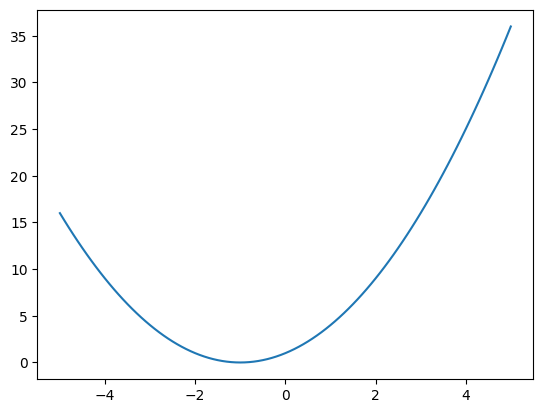

In [36]:
plt.plot(x_vals,y_vals)

In [37]:
list(zip(x_vals,y_vals))

[(-5.0, 16.0),
 (-4.9, 15.210000000000003),
 (-4.800000000000001, 14.440000000000005),
 (-4.700000000000001, 13.690000000000008),
 (-4.600000000000001, 12.96000000000001),
 (-4.500000000000002, 12.250000000000012),
 (-4.400000000000002, 11.560000000000015),
 (-4.3000000000000025, 10.890000000000017),
 (-4.200000000000003, 10.240000000000018),
 (-4.100000000000003, 9.610000000000019),
 (-4.0000000000000036, 9.000000000000021),
 (-3.9000000000000035, 8.41000000000002),
 (-3.8000000000000034, 7.8400000000000185),
 (-3.7000000000000033, 7.290000000000018),
 (-3.600000000000003, 6.760000000000017),
 (-3.500000000000003, 6.250000000000015),
 (-3.400000000000003, 5.760000000000015),
 (-3.300000000000003, 5.290000000000013),
 (-3.200000000000003, 4.840000000000012),
 (-3.1000000000000028, 4.410000000000012),
 (-3.0000000000000027, 4.000000000000011),
 (-2.9000000000000026, 3.6100000000000096),
 (-2.8000000000000025, 3.240000000000009),
 (-2.7000000000000024, 2.890000000000008),
 (-2.6000000000

How about a python function that finds the minimum of a mathematical function:

In [38]:
def a_function(x):
    return (1+x)**2

def find_min_0(f,x_min,x_max,steps=10):
    
    step_size=(x_max-x_min)/steps
    x=x_min
    y_min=f(x_min)
    x_min_val=x_min

    for i in range(steps):
        y=f(x)
        if y<y_min:
            x_min_val=x
            y_min=y
        x+=step_size
    
    return x_min_val

In [39]:
find_min_0(a_function,-10,10,100)

-1.000000000000002

## Functional Programming

In lab 2 you built a tic-tac-toe game by implementing a series of functions that performed various tasks, which you then combined in various ways to implement the game logic. What you wrote was a *structured program*, which consist of sequences of instructions, utilizing control flow (if/then/else), repetition (while and for), block structures, and function calls. 

*Functional Programming* is another style of programming that is not well suited to writing games, but is well suited to manipulating data. A functional program performs computation by evaluating functions, where the output only depend on the input. Data passes through as inputs/outputs of functions, but is otherwise never changed. This paradigm is often used in data science because manipulation of data can othen be viewed as composition of functions:

$$
D_{result} = f_n(f_{n-1}(...(f_0(D_{input}))))
$$

You already have the pieces. Earlier you met list comprehensions, `map`, `lambda`, and
closures, and the uniform generator at the top of this notebook is a closure. What changes here
is how you *use* them: the loop-and-accumulate version of `find_min` and the composed version
below compute the same answer, but the second one is written as data flowing through a chain of
transformations, which is the shape almost all data manipulation takes.

Lets write the function minimizer in a more functional way by realizing that we can perform the same task as a set of composition of functions:

In [40]:
def linspace(x_min,x_max,steps=10):
    x=x_min
    step_size=(x_max-x_min)/steps
    out=list()
    while x<x_max:
        out.append(x)
        x+=step_size
    return out

def arg_min(lst):
    min_val=lst[0]
    min_index=0
    for i,val in enumerate(lst):
        if val<min_val:
            min_val=val
            min_index=i
            
    return min_index


Now lets write `find_min` in a more function way. Here is the original again:

In [41]:
def find_min_0(f,x_min,x_max,steps=10):
    
    step_size=(x_max-x_min)/steps
    x=x_min
    y_min=f(x_min)
    x_min_val=x_min

    for i in range(steps):
        y=f(x)
        if y<y_min:
            x_min_val=x
            y_min=y
        x+=step_size
    
    return x_min_val

This function:
* Loops in "step", where in each step
   * Considers a specific value of `x`, starting with `x_min`.
   * Calculates `y=f(x)`.
   * Keeps track of the minimum value of `y` found so far, and the associated `x`.
   * Increments `x`.
* Returns the value of `x` where `y` was the lowest.

Lets think through the steps of implementing `find_min` functionally:
* Create a list of all values of `x`.
* Use that list to create all values of `y`.
* Find the `arg_min` of lowest value of `y`. 
* Return the `x` value for lowest value of `y`.

Here is the implementation:

In [42]:
def find_min_0(f,x_min,x_max,steps=100):
    x_vals=linspace(x_min,x_max,steps)
    y_vals=list(map(f,x_vals))
    index=arg_min(y_vals)
    return x_vals[index]

# Same thing... all in one line.
def find_min(f,x_min,x_max,steps=100):
    return linspace(x_min,x_max,steps)[arg_min(list(map(f,linspace(x_min,x_max,steps))))]


In [43]:
find_min_0(a_function,-10.,10.,100)

-1.000000000000002

As a side, lets work out how to implement `a_range` recursively:

In [44]:
def a_range(x_min,x_max,steps=10):
    if steps>1:
        return [x_min] + a_range(x_min+((x_max-x_min)/steps),x_max,steps-1)
    else:
        return [x_min]

def a_range_0(x_min,x_max,steps=10):
    [x_min] + a_range(x_min+((x_max-x_min)/steps),x_max,steps-1) if steps>1 else [x_min]
        

We are not going to write functions this way, but the idea is to get familiar with seeing data manipulations as a composition of functions.

# Histograms

A histogram is the estimator of a probability distribution — that is the claim from
earlier, and this section is where you build one.

Strip away the picture and a histogram is exactly two lists:

1. the **location of the bin edges**
2. the **count in each bin**

Everything else is presentation. And the connection back to the distribution is the formula from
before,

$$P(x) \approx \frac{n(x)}{N\,\Delta x}$$

where $n(x)$ is the count in the bin containing $x$, $N$ is the total number of data points, and
$\Delta x$ is the bin width. Dividing by $N$ turns counts into fractions; dividing by $\Delta x$
removes your arbitrary choice of binning from the answer.

We'll look at what `numpy` and `matplotlib` give you first, and then write the whole thing from
scratch.

In [45]:
# Quickly make a list of 100 numbers between 5 and 15.
data_0=(10*np.random.random(100)+5.).tolist()
print(data_0)

[9.920629451081133, 8.073886616017298, 12.683947911399436, 14.701335704340632, 13.093743767676305, 6.2925503282525685, 10.467113521846425, 8.259604264559083, 12.917700018524519, 7.5095908531877456, 8.96206794136047, 12.573309289528023, 8.351799224363749, 6.656402308505985, 8.675335202521778, 8.0065314078332, 9.231624852502978, 5.294087991894103, 7.072505476497146, 10.878148998647811, 7.197595126098404, 5.043093638490949, 8.718772834358564, 6.643811324826308, 5.819665830634898, 7.581983688433644, 12.51715910077877, 11.306945323990313, 8.980209710355645, 13.38688996377625, 12.802170434404282, 11.779257540203098, 10.104767459681732, 14.822945457416832, 14.014715613661945, 14.505526527706216, 9.591398233253717, 6.882788336480781, 13.908478720420426, 9.277084248374257, 9.05407070045645, 7.225920964291934, 10.454574790489634, 6.521562247907546, 10.063624094356687, 13.67975561552384, 12.713417780491534, 8.136820785563781, 14.614403198436563, 12.385249813872221, 6.344805916077874, 14.850856655

In [46]:
# Or a normal distribution at 10 with sigma 2.5
data_1=np.random.normal(10,2.5,1000)

In [47]:
np.histogram(data_0,bins=1)

(array([100]), array([ 5.04309364, 14.90637936]))

In [48]:
print(min(data_0),max(data_0))

5.043093638490949 14.906379356533632


In [49]:
np.histogram(data_0,bins=2)

(array([53, 47]), array([ 5.04309364,  9.9747365 , 14.90637936]))

In [50]:
np.histogram(data_0,bins=3)

(array([36, 31, 33]),
 array([ 5.04309364,  8.33085554, 11.61861745, 14.90637936]))

(array([36., 31., 33.]),
 array([ 5.04309364,  8.33085554, 11.61861745, 14.90637936]),
 <BarContainer object of 3 artists>)

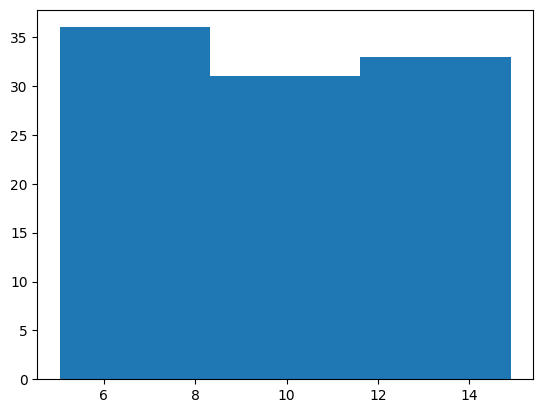

In [51]:
plt.hist(data_0,bins=3)

(array([  8.,  41.,  90., 200., 256., 227., 122.,  42.,  11.,   3.]),
 array([ 2.67159524,  4.27752895,  5.88346266,  7.48939637,  9.09533008,
        10.70126379, 12.3071975 , 13.91313121, 15.51906492, 17.12499862,
        18.73093233]),
 <BarContainer object of 10 artists>)

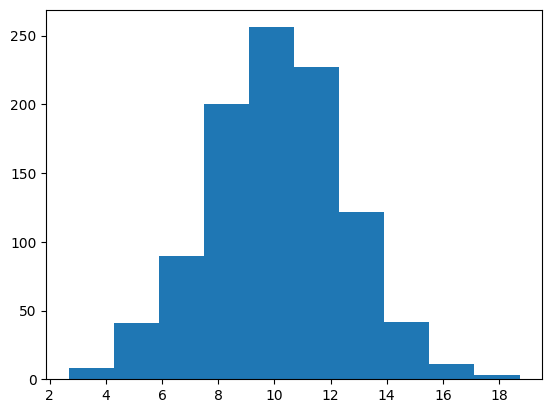

In [52]:
plt.hist(data_1)

In [53]:
np.mean(data_1)

np.float64(10.094444970412844)

In [54]:
np.std(data_1)

np.float64(2.458573386228348)

## Histogram

In Lab 3 you are asked to write a histogram function:

* User inputs a list of values `x` and optionally `n_bins` which defaults to 10.
* If not supplied, find the minimum and maximum (`x_min`,`x_max`) of the values in x.
* Determine the bin size (`bin_size`) by dividing the range of the function by the number of bins.
* Create an empty list of zeros of size `n_bins`, call it `hist`.
* Loop over the values in `x`
    * Loop over the values in `hist` with index `i`:
        * If x is between `x_min+i*bin_size` and `x_min+(i+1)*bin_size`, increment `hist[i].` 
        * For efficiency, try to use continue to goto the next bin and data point.
* Return `hist` and the list corresponding of the bin edges (i.e. of `x_min+i*bin_size`).    

The nested loop is the honest version: for each data point, walk the bins until you find the one
it belongs to, increment it, and stop looking. That inner `break` matters — a value lands in
exactly one bin, so once you have found it there is no reason to keep checking the rest.

This is what `np.histogram` is doing. It is faster, because the loop runs in compiled code rather
than in Python, and it handles the edge cases you would otherwise have to think about. But there
is nothing in it you haven't just written.

## Alternative
* User inputs a list of values `x` and optionally `n_bins` which defaults to 10.
* If not supplied, find the minimum and maximum (`x_min`,`x_max`) of the values in x.
* Create an empty list of zeros of size `n_bins`, call it `hist`.
* Create a list of `bin_edges` using `arange`.
* Append the `x_max` to bin_edges.
* Loop over the values in `x`
    * Loop over the values in `hist` with index `i`:
        * If x is between `bin_edge[i]` and `bin_edge[i+1]`, increment `hist[i].` 
        * For efficiency, try to use continue to goto the next bin and data point.
* Return `hist` and the list corresponding of the bin edges (i.e. of `x_min+i*bin_size`).    



In [55]:
def histogram(data, n_bins=10,x_min=None, x_max=None):
    if x_min==None:
        x_min=min(data)
    if x_max==None:
        x_max=max(data)
        
    bin_edges = linspace(x_min,x_max,n_bins)
    bin_edges.append(x_max)

    hist=[0]*n_bins
    
    for d in data:
        for i,(low_edge,high_edge) in enumerate(zip(bin_edges[:-1],bin_edges[1:])):
            if d>=low_edge and d<high_edge:
                hist[i]+=1
                break
                
    return hist,bin_edges

In [56]:
histogram(data_0,10,0,10)

([0, 0, 0, 0, 0, 9, 13, 10, 12, 9],
 [0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10])

In [57]:
np.histogram(data_0,range=(0,10),bins=10)

(array([ 0,  0,  0,  0,  0,  9, 13, 10, 12,  9]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.]))

## Accept/Reject

**Reminder.** Inversion needed an integral you could do analytically. Usually you
can't — you have an $f$ you can *evaluate* and not integrate. Accept/reject asks nothing more than
evaluation:

> Draw the box around the function. Throw darts into it uniformly. Keep the $x$ of every dart that
> lands **under** the curve; throw the rest away.

We argued earlier why the kept values come out distributed like $f$ (a thin strip at $x$ keeps a
fraction $f(x)/y_{max}$ of its darts — proportional to the height of $f$ there) and what it costs
(every rejected dart is a wasted evaluation). Here you build it.

Note what you are trading. The exponential generator above did **one** uniform draw per sample.
This does **at least two**, and throws most of them away when $f$ is peaked. In exchange it works
on any function at all.

Inputs: 

* function `f`
* number of points to generate `n`
* range to generate within `x_min`, `x_max`
* optional `n_steps`, defaulting to 100, used for finding min/max.
 
Strategy:

1. Find `y_min` and `y_max` of function `f` over input range.
    1. Create/use new function `find_min_max` analgous to `find_min` above. 
1. Create output list to hold values.
1. Use `while` statement to loop until length of output list is `n`.
    1. Draw 2 random numbers from uniform distribution:
        1. `x` in range [`x_min`,`x_max`] 
        1. `y` in range [`y_min`,`y_max`] 
    1. if `y` < `f(x)`, append `x` to output list.
1. Return output list.


### Checking that it worked

What comes back is a **sample** — a list of `x` values — not a curve. Verify it the obvious way:
histogram your output with the `histogram` function you wrote above and compare the shape to `f`.
It should reproduce `f` up to normalisation and counting noise.

Build the habit. A sampler that is subtly wrong — a range mis-specified, a comparison the wrong
way round — still returns a perfectly plausible list of numbers, and the histogram is the only
thing that gives it away.

### Computing Integral

The same loop also **integrates** `f`, and it costs you nothing extra: you threw darts uniformly
into a box of known area, so the fraction landing under the curve is the fraction of that area
lying under the curve.

$$\int_{x_{min}}^{x_{max}} f(x)\,dx \;=\; A \times \frac{\#\,\text{accepts}}{\#\,\text{trials}}
\qquad A = (x_{max}-x_{min})(y_{max}-y_{min})$$

The integral should be `(x_max - x_min)*(y_max - y_min)` times the fraction of times that `y` < `f(x)`.

So return the count of accepts alongside the sample and you have both. We covered earlier why
**Monte Carlo integration** matters — no calculus, and a cost that does not explode with
dimensions — and where its accuracy comes from: $n$ accepts carry $\sqrt{n}$ uncertainty, so the
relative error on the integral is $1/\sqrt{n}$.

**Try it.** Integrate something you know the answer to — a Gaussian over a wide range should give
you $1$ — and watch the error shrink as $1/\sqrt{n}$ when you increase the number of trials. That
is the counting-statistics law we saw earlier, showing up in code you wrote.

## Percentiles from a Cumulative Sum

One more thing you can do with a histogram, and it is the one that comes up most often in
practice.

The cumulative distribution answers "what fraction of the data lies below $x_1$?" Run it backwards
and it answers something more useful: "**below what value does 90% of the data lie?**" That is the
90th percentile, $x_{90}$. Medians, quartiles and every percentile you have ever seen quoted are
this same calculation.

You rarely have a formula for the cumulative, but you always have the data. The recipe:

1. **Generate** a sample — say 1000 values drawn from a normal distribution, `x ~ N(x)`.
2. **Histogram** it. That gives you a list of counts.
3. **Cumulative sum** down that list: entry $i$ becomes the number of data points at or below
   bin $i$. A running total.
4. The last entry is $N$, the total. **Find where the running total first reaches $0.9N$** — with
   1000 points, where it passes 900.
5. **Return that bin's edge.** That is $x_{90}$.

Step 3 is the only new operation, and it is a three-line loop: keep a running total, append it,
move on. Write it yourself before reaching for `np.cumsum`.

Two properties worth understanding, because they explain a lot of confusing plots:

* **The answer is always a bin edge**, so its resolution is your bin width. A percentile taken
  from a coarse histogram is coarse, and no amount of data fixes that — only narrower bins do.
* **Nothing here assumed a distribution.** No normality, no functional form, nothing fitted. It
  works on any sample at all, which is exactly why percentiles are quoted for data that is nothing
  like normal — and why they are often a more honest summary than a mean and a standard
  deviation.

That last point connects back to the warning from earlier. If your data is two populations
superimposed, the mean describes neither — but the median and the quartiles still describe the
data you actually have.